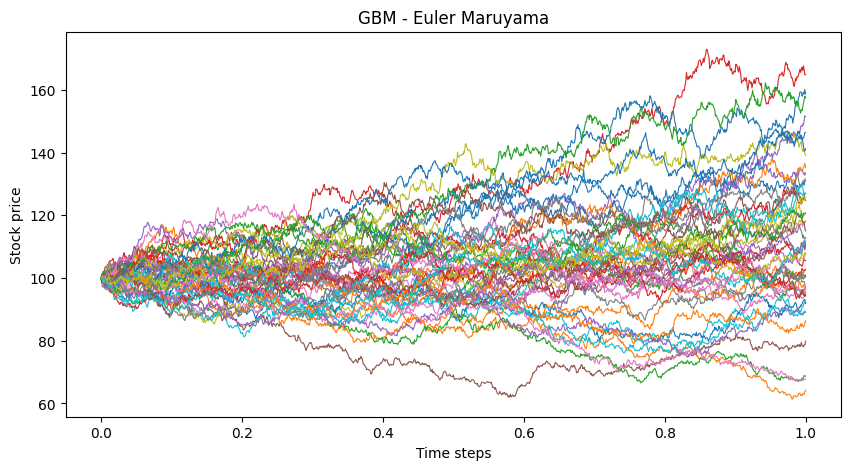

In [1]:
import numpy as np
import matplotlib.pyplot as plt

S0=100
mu=0.1
sigma=0.2
T=1
N=1000
dt=T/N
paths=100000

Z=np.random.randn(paths,N)
dW=np.sqrt(dt)*Z

S=np.zeros((paths,N+1))
S[:,0]=S0

for n in range(N):
  S[:,n+1]=S[:,n] + mu*S[:,n]*dt + sigma*S[:,n]*dW[:,n]

plt.figure(figsize=(10,5))
t=np.linspace(0,T,N+1)
for i in range(50):
  plt.plot(t,S[i],lw=0.8)


plt.xlabel('Time steps')
plt.ylabel('Stock price')
plt.title('GBM - Euler Maruyama')
plt.show()

[np.float64(0.7808815582436919), np.float64(0.24886686748097445), np.float64(0.07909772704294345), np.float64(0.024941807517841804)]


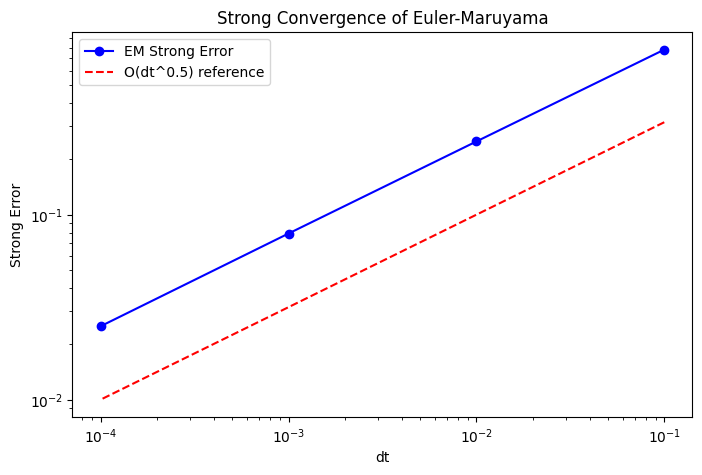

In [4]:
dt_values=[0.1,0.01,0.001,0.0001]
strong_errors=[]
paths = 100000
strong_errors = []

for dt in dt_values:
    N = int(T/dt)

    S_em = np.zeros((paths, N+1))
    S_em[:, 0] = S0
    W_T = np.zeros(paths)

    for n in range(N):
        dW = np.sqrt(dt) * np.random.randn(paths)
        W_T += dW
        S_em[:, n+1] = S_em[:, n] * (1 + mu*dt + sigma*dW)

    S_exact = S0 * np.exp((mu - sigma**2/2)*T + sigma*W_T)
    error = np.mean(np.abs(S_exact - S_em[:, -1]))
    strong_errors.append(error)

print(strong_errors)
plt.figure(figsize=(8,5))
plt.loglog(dt_values,strong_errors,'bo-',label='EM Strong Error')
plt.loglog(dt_values,[dt**0.5 for dt in dt_values],'r--',label='O(dt^0.5) reference')
plt.xlabel('dt')
plt.ylabel('Strong Error')
plt.title('Strong Convergence of Euler-Maruyama')
plt.legend()
plt.show()

[np.float64(0.05325351623679872), np.float64(0.006842769398171957), np.float64(0.0006594865307993022), np.float64(0.00016968957153741697)]


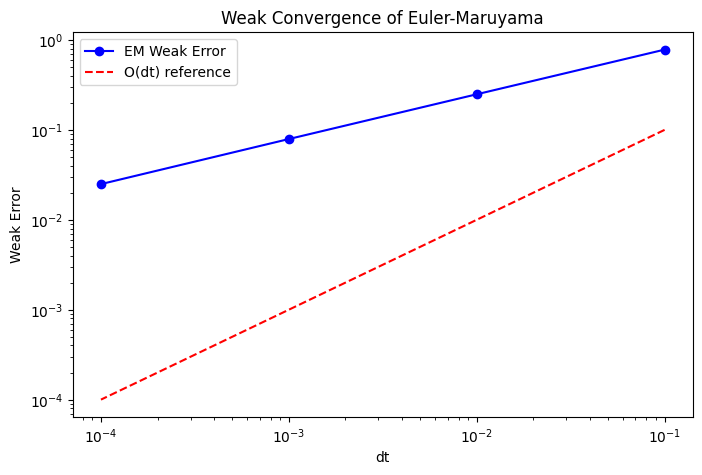

In [5]:
dt_values=[0.1,0.01,0.001,0.0001]
weak_errors=[]
paths = 100000
for dt in dt_values:
    N = int(T/dt)

    S_em = np.zeros((paths, N+1))
    S_em[:, 0] = S0
    W_T = np.zeros(paths)

    for n in range(N):
        dW = np.sqrt(dt) * np.random.randn(paths)
        W_T += dW
        S_em[:, n+1] = S_em[:, n] * (1 + mu*dt + sigma*dW)

    S_exact = S0 * np.exp((mu - sigma**2/2)*T + sigma*W_T)
    error = np.abs(np.mean(S_exact - S_em[:, -1]))
    weak_errors.append(error)

print(weak_errors)

plt.figure(figsize=(8,5))
plt.loglog(dt_values,strong_errors,'bo-',label='EM Weak Error')
plt.loglog(dt_values,[dt for dt in dt_values],'r--',label='O(dt) reference')
plt.xlabel('dt')
plt.ylabel('Weak Error')
plt.title('Weak Convergence of Euler-Maruyama')
plt.legend()
plt.show()